In [2]:
import pandas as pd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
regulon_tval_per_celltype = pd.read_csv('regulon_heatmap_filtered_epi/regulon_tvalues_per_celltype.csv')
regulon_tval_per_celltype.rename(columns={'Unnamed: 0':'TF'}, inplace=True)
regulon_tval_per_celltype.head()

,TF,BasalEpi_Acta2+Trp63,Epi_Ctr9+,Epi_Kit+Elf5+,Epi_proliferating
0,Aebp2(+),-1.885510,-7.867038,8.392562,-0.274008
1,Ahr(+),-2.917597,-17.207722,18.307028,-2.488219
2,Alx4(+),29.307249,-15.044386,-10.589392,-1.928313
3,Ar(+),-1.209943,-0.653548,2.534108,-2.025429
4,Arid3a(+),14.120268,-2.194602,-8.769185,-3.725197


In [4]:
# Create filtered and sorted df
epi_ctr9_ranks = (
    regulon_tval_per_celltype[['TF', 'Epi_Ctr9+']]
    .sort_values('Epi_Ctr9+', ascending=True)
    .reset_index(drop=True)
)
epi_ctr9_ranks.index += 1  # 1-based rank
epi_ctr9_ranks.index.name = 'rank'

epi_ctr9_ranks.head()

,TF,Epi_Ctr9+
rank,,
1,Nfib(+),-64.748946
2,Nfix(+),-56.309812
3,Pbx1(+),-54.135191
4,Sox10(+),-51.549294
5,Tcf7l1(+),-47.944110


In [5]:
def lookup_tf(tf_name):
    result = epi_ctr9_ranks[epi_ctr9_ranks['TF'] == tf_name]
    if result.empty:
        print(f"'{tf_name}' not found. Try a partial match:")
        print(epi_ctr9_ranks[epi_ctr9_ranks['TF'].str.contains(tf_name, case=False)])
    else:
        rank = result.index[0]
        total = len(epi_ctr9_ranks)
        val = result['Epi_Ctr9+'].values[0]
        print(f"{tf_name} → rank {rank} / {total}  (t-value: {val:.3f})")
        return result

lookup_tf('Sox4(+)')

Sox4(+) → rank 414 / 455  (t-value: 6.950)


,TF,Epi_Ctr9+
rank,,
414,Sox4(+),6.949932


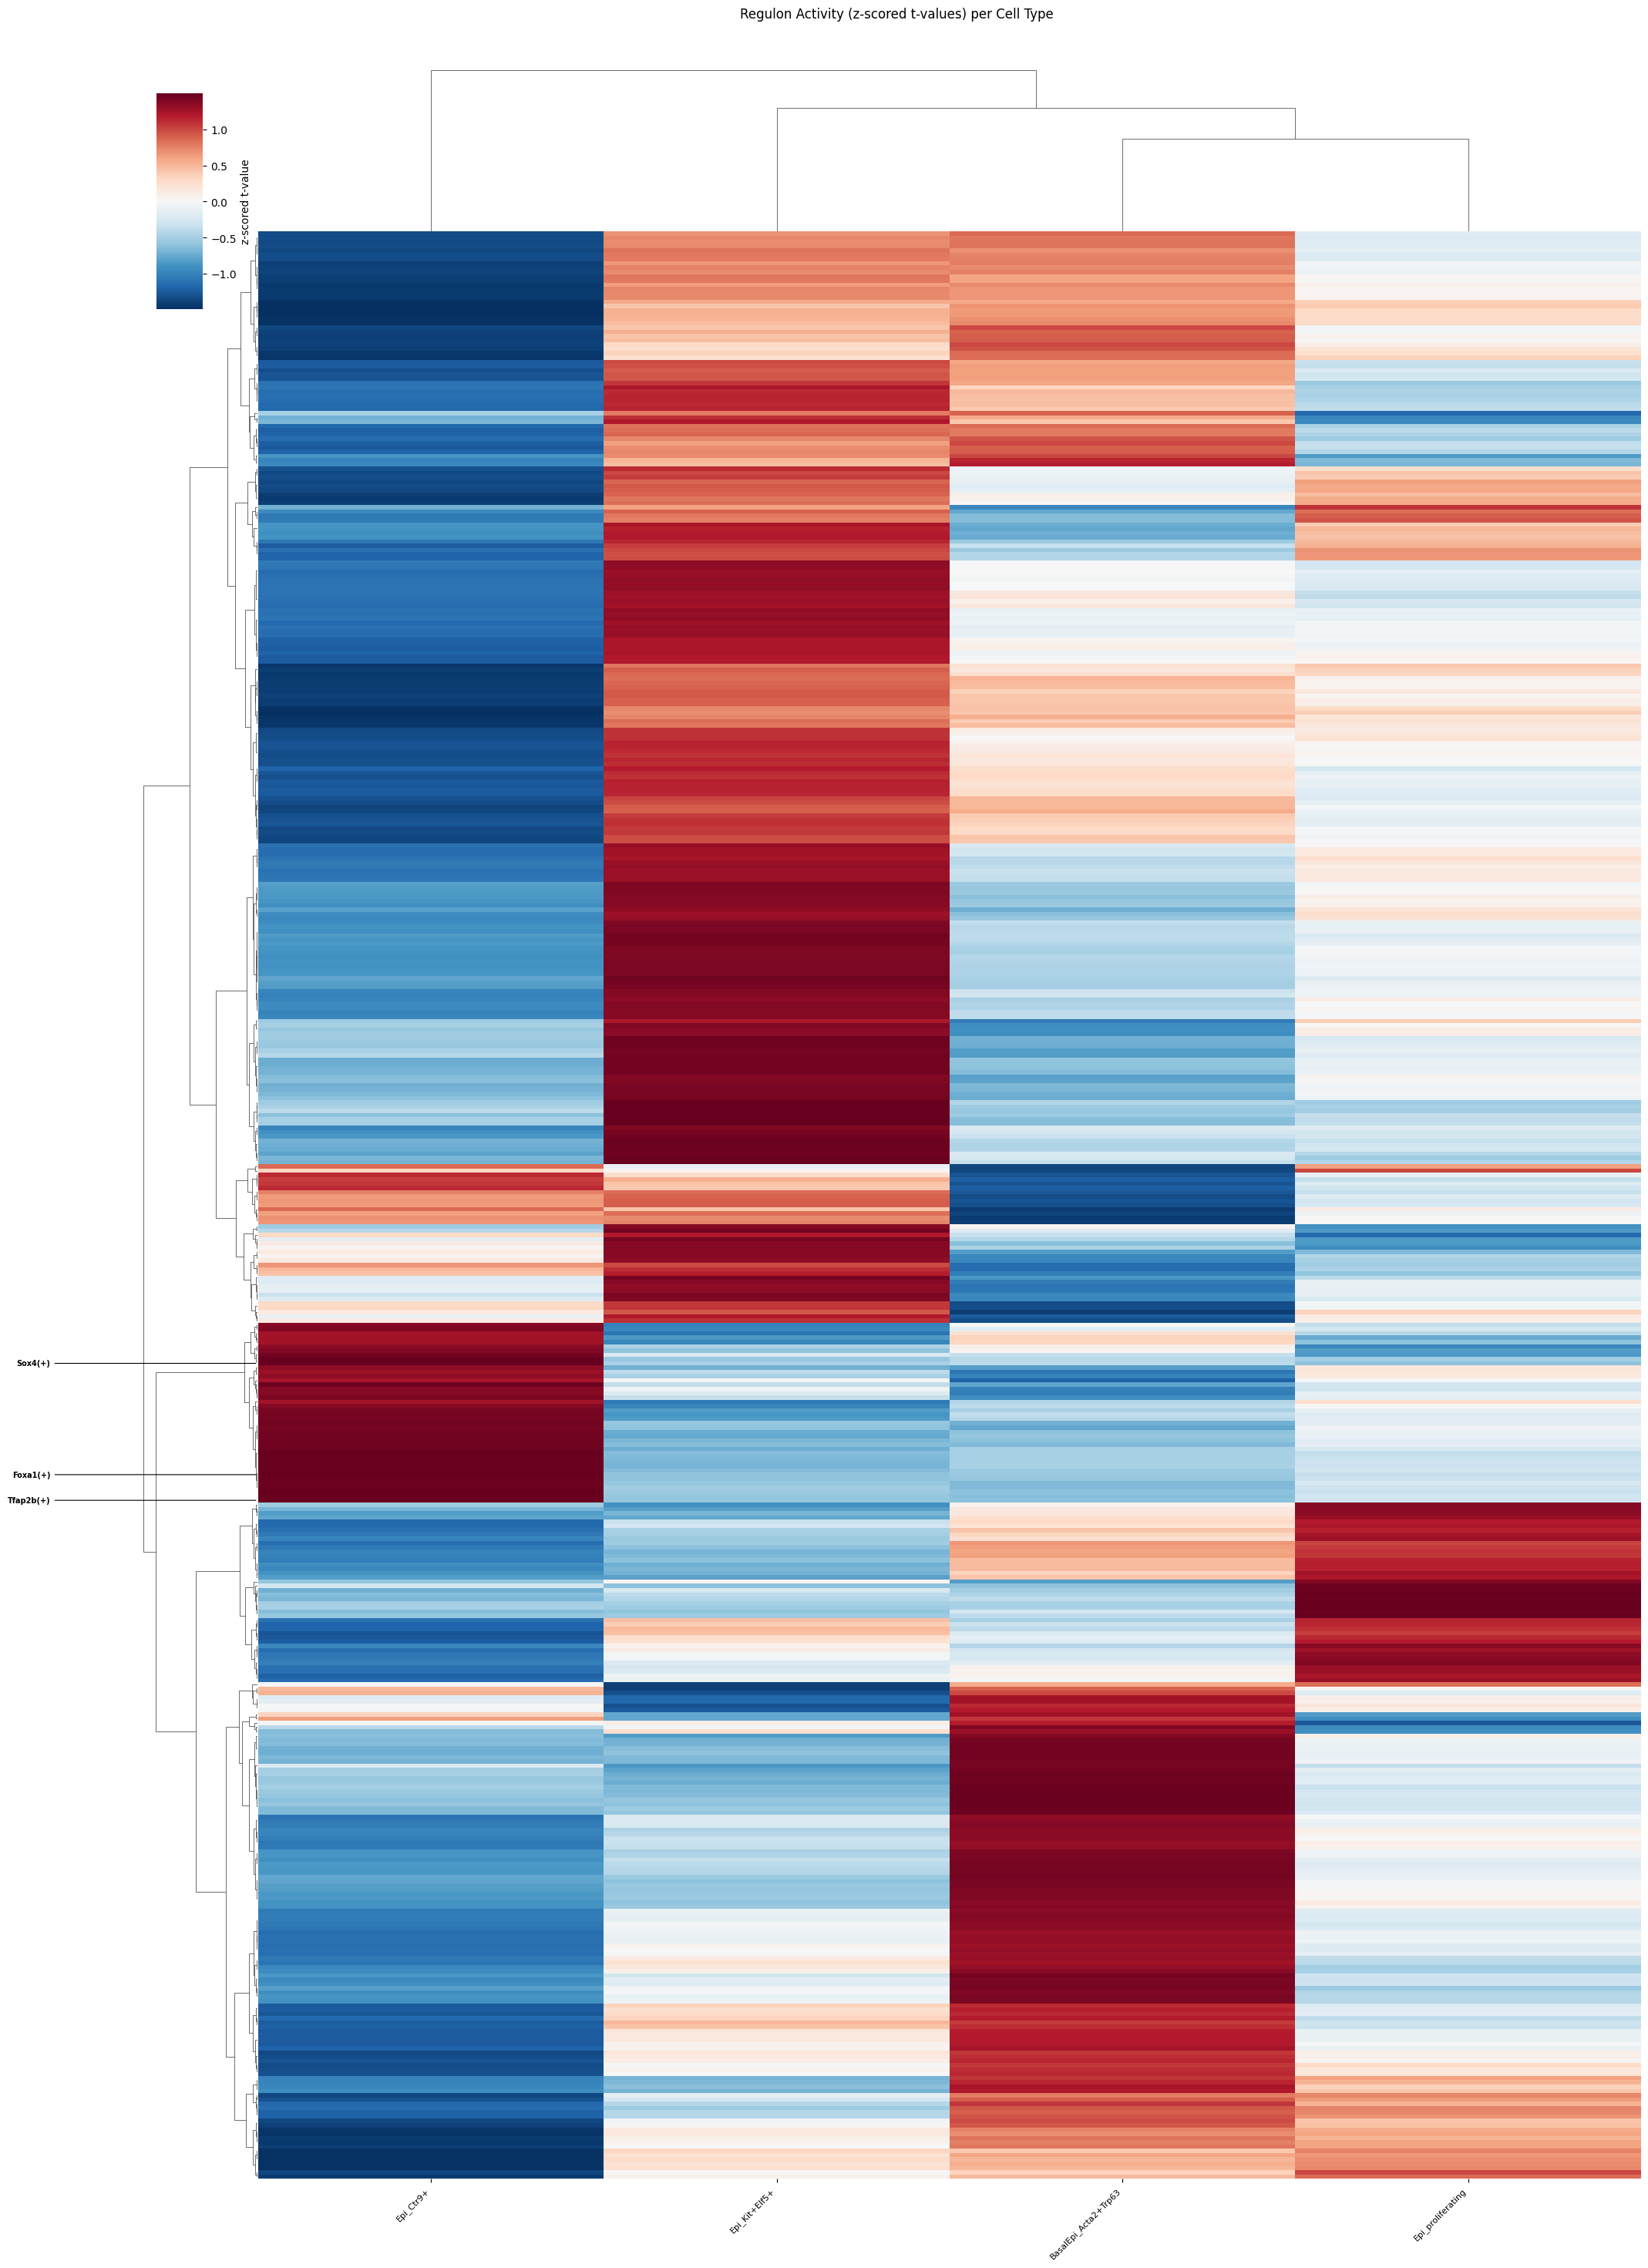

In [ ]:
tfs_to_label = ['Tfap2b', 'Foxa1', 'Sox4']

df = regulon_tval_per_celltype.set_index('TF')

g = sns.clustermap(
    df,
    z_score=0,
    cmap='RdBu_r',
    center=0,
    figsize=(20, max(28, len(df) * 0.04)),
    yticklabels=False,
    xticklabels=True,
    dendrogram_ratio=(0.08, 0.08),
    cbar_kws={'label': 'z-scored t-value'},
    cbar_pos=(0.02, 0.88, 0.03, 0.1),   # (left, bottom, width, height)
    method='ward',
    metric='euclidean',
)

# Get reordered index after clustering
reordered_idx = g.dendrogram_row.reordered_ind
reordered_tfs = df.index[reordered_idx]

ax = g.ax_heatmap
for i, tf in enumerate(reordered_tfs):
    tf_clean = tf.replace('(+)', '')
    if tf_clean in tfs_to_label:
        y = i + 0.5
        ax.annotate(
            tf,
            xy=(0, y),
            xytext=(-0.6, y),
            fontsize=7, fontweight='bold', va='center', ha='right',
            arrowprops=dict(arrowstyle='-', color='black', lw=0.8),
            clip_on=False,
            annotation_clip=False,
        )

ax.set_xticklabels(ax.get_xticklabels(), fontsize=8, rotation=45, ha='right')
ax.set_ylabel('')
g.fig.suptitle('Regulon Activity (z-scored t-values) per Cell Type', y=1.02)
plt.show()